# FreeVIZ and SPCA comparison

In this notebook, we compare resulting vizualizations of FreeViz and SPCA for classification on four datasets.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import torch
import matplotlib.pyplot as plt
import numpy as np

import importlib
import utils
importlib.reload(utils)

from models import Freeviz
from models.spca_classification import SPCA_Classification
from utils import load_zoo_data, load_car_data, load_mushroom_data, load_glass_data, load_breast_cancer_data, scale_features, plot_projection, select_lambda_classification

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# The ZOO dataset

#### Data preparation

In [3]:
E_raw, C, names, feature_names, class_names = load_zoo_data(device)
E = scale_features(E_raw)

In [4]:
# Select optimal lambda for SPCA on Zoo data
E_zoo_f64 = E.to(torch.float64)
best_lam_zoo = select_lambda_classification(SPCA_Classification, E_zoo_f64, C,
                             num_classes=len(class_names), steps=500)


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Step 0: loss = 1.8597, classifier loss = 1.8516
Step 10: loss = 1.1988, classifier loss = 1.1894
Step 20: loss = 0.9331, classifier loss = 0.9226
Step 30: loss = 0.8036, classifier loss = 0.7929
Step 40: loss = 0.6967, classifier loss = 0.6857
Step 50: loss = 0.5995, classifier loss = 0.5876
Step 60: loss = 0.5234, classifier loss = 0.5109
Step 70: loss = 0.4621, classifier loss = 0.4494
Step 80: loss = 0.4110, classifier loss = 0.3981
Step 90: loss = 0.3676, classifier loss = 0.3544
Step 100: loss = 0.3304, classifier loss = 0.3170
Step 110: loss = 0.2984, classifier loss = 0.2849
Step 120: loss = 0.2709, classifier loss = 0.2571
Step 130: loss = 0.2470, classifier loss = 0.2331
Step 140: loss = 0.2263, classifier loss = 0.2123
Step 150: loss = 0.2082, classifier loss = 0.1941
Step 160: loss = 0.1924, classifier loss = 0.1781
Step 170: loss = 0.1784, classifier loss = 0.1640
Step 180: loss = 0.1658, classifier loss = 0.1514
Step 190: loss = 0.1545, classifier loss = 0.1400
Step 200: l

#### Train FreeVIZ

In [5]:
freeviz = Freeviz(E.shape[1]).to(device)
freeviz.train(E, C)

P = freeviz(E)
A = freeviz.A
P_np = P.detach().cpu().numpy()
C_np = C.detach().cpu().numpy()
A_np = A.detach().cpu().numpy()

step: 1 loss: 18686.888671875
step: 2 loss: 18908.2890625
step: 3 loss: 20747.513671875
step: 4 loss: 19672.515625
step: 5 loss: 12327.8173828125
step: 6 loss: 11816.6328125
step: 7 loss: 11520.2734375
step: 8 loss: 11745.88671875
step: 9 loss: 12014.47265625
step: 10 loss: 12151.3095703125
step: 11 loss: 12283.1416015625


#### Train SPCA Classification

In [6]:
model = SPCA_Classification(input_dim=E.shape[1], latent_dim=2, num_classes=len(class_names), lr=0.05).to(device)
E_centered = E - E.mean(dim=0)
lam = best_lam_zoo
steps = 1000
model.train(E_centered, C, lam=lam, steps=steps, classifier_epochs=50)

L = model.L.detach().clone()
L = L - L.mean(dim=0, keepdim=True)
loading_norms = torch.norm(L, dim=1)
L = L / loading_norms.max()

Z = E_centered @ L
z_max = torch.abs(Z).max()
Z = Z / z_max

Z_np = Z.cpu().numpy()
C_np_spca = C.cpu().numpy()
L_np = L.cpu().numpy()

Step 0: loss = 2.7018, classifier loss = 1.8483
Step 10: loss = 2.0390, classifier loss = 1.1803
Step 20: loss = 1.7718, classifier loss = 0.9098
Step 30: loss = 1.6462, classifier loss = 0.7828
Step 40: loss = 1.5701, classifier loss = 0.7054
Step 50: loss = 1.5152, classifier loss = 0.6492
Step 60: loss = 1.4716, classifier loss = 0.6042
Step 70: loss = 1.4353, classifier loss = 0.5663
Step 80: loss = 1.4042, classifier loss = 0.5335
Step 90: loss = 1.3769, classifier loss = 0.5043
Step 100: loss = 1.3525, classifier loss = 0.4768
Step 110: loss = 1.3282, classifier loss = 0.4460
Step 120: loss = 1.2993, classifier loss = 0.4020
Step 130: loss = 1.2674, classifier loss = 0.3522
Step 140: loss = 1.2397, classifier loss = 0.3128
Step 150: loss = 1.2168, classifier loss = 0.2831
Step 160: loss = 1.1978, classifier loss = 0.2597
Step 170: loss = 1.1816, classifier loss = 0.2407
Step 180: loss = 1.1675, classifier loss = 0.2248
Step 190: loss = 1.1551, classifier loss = 0.2112
Step 200: l

### Side-by-side comparison

/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


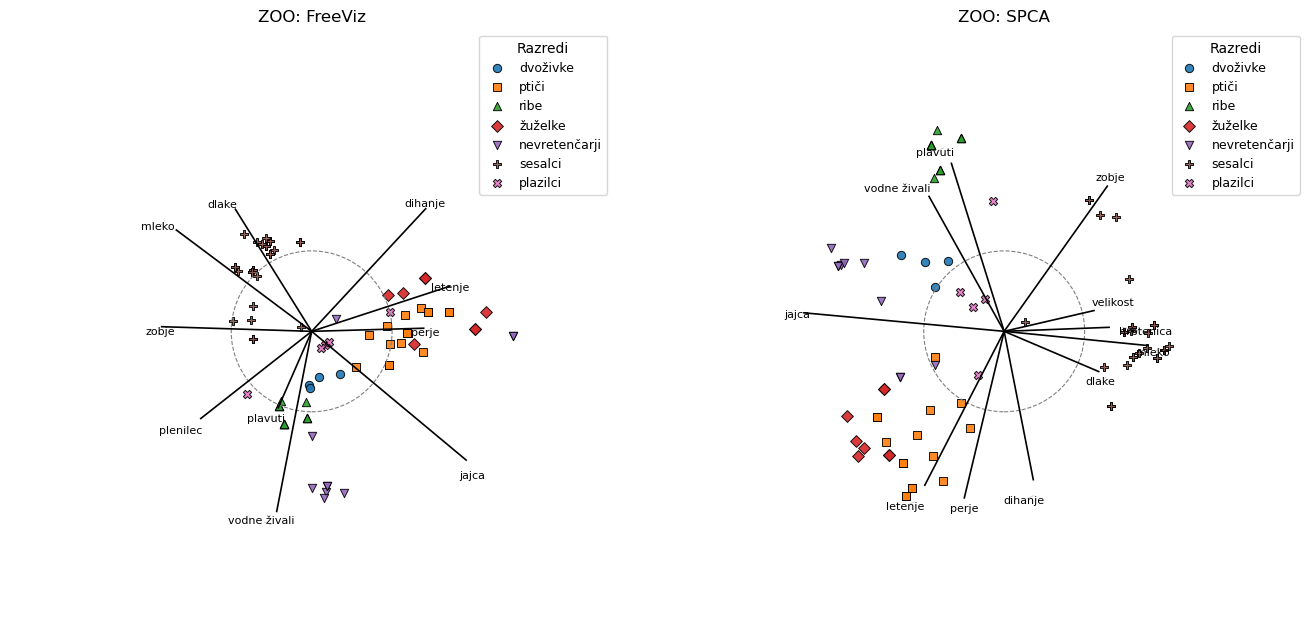

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    P_np, A_np, feature_names, C_np, class_names,
    title='ZOO: FreeViz', ax=ax1, text_scale=1.08, normalize_points=True
)

plot_projection(
    Z_np, L_np, feature_names, C_np_spca, class_names,
    title='ZOO: SPCA', ax=ax2, text_scale=1.1
)

plt.tight_layout()
plt.savefig("../final_vizualizations/compare_freeviz_spca_zoo.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/compare_freeviz_spca_zoo.png", format="png", bbox_inches="tight")
plt.show()

# The MUSHROOM dataset

#### Data preparation

In [8]:
E_mush, C_mush, names_mush, feature_names_mush, class_names_mush = load_mushroom_data(device)
E_mush = scale_features(E_mush)

In [9]:
# Select optimal lambda for SPCA on Mushroom data
E_mush_f64 = E_mush.to(torch.float64)
best_lam_mush = select_lambda_classification(SPCA_Classification, E_mush_f64, C_mush,
                             num_classes=len(class_names_mush), steps=500)


Step 0: loss = 1.2540, classifier loss = 0.6351
Step 10: loss = 0.9739, classifier loss = 0.3463
Step 20: loss = 0.8786, classifier loss = 0.2407
Step 30: loss = 0.8314, classifier loss = 0.1851
Step 40: loss = 0.8025, classifier loss = 0.1501
Step 50: loss = 0.7827, classifier loss = 0.1259
Step 60: loss = 0.7683, classifier loss = 0.1082
Step 70: loss = 0.7574, classifier loss = 0.0951
Step 80: loss = 0.7560, classifier loss = 0.0931
Step 90: loss = 0.7548, classifier loss = 0.0917
Step 100: loss = 0.7536, classifier loss = 0.0904
Step 110: loss = 0.7525, classifier loss = 0.0891
Step 120: loss = 0.7514, classifier loss = 0.0878
Step 130: loss = 0.7503, classifier loss = 0.0865
Step 140: loss = 0.7492, classifier loss = 0.0853
Step 150: loss = 0.7482, classifier loss = 0.0841
Step 160: loss = 0.7471, classifier loss = 0.0829
Step 170: loss = 0.7461, classifier loss = 0.0817
Step 180: loss = 0.7451, classifier loss = 0.0806
Step 190: loss = 0.7441, classifier loss = 0.0795
Step 200: l

#### Train FreeVIZ

In [10]:
freeviz_mush = Freeviz(E_mush.shape[1]).to(device)
freeviz_mush.train(E_mush, C_mush)

P_mush = freeviz_mush(E_mush)
A_mush = freeviz_mush.A
P_mush_np = P_mush.detach().cpu().numpy()
C_mush_np = C_mush.detach().cpu().numpy()
A_mush_np = A_mush.detach().cpu().numpy()

step: 1 loss: 11156914.0
step: 2 loss: 2270743.25
step: 3 loss: 2286272.25
step: 4 loss: 2316779.0
step: 5 loss: 2224857.0
step: 6 loss: 2199510.5
step: 7 loss: 2204252.25
step: 8 loss: 2171202.75
step: 9 loss: 2179453.0
step: 10 loss: 2232810.5
step: 11 loss: 2246996.75


#### Train SPCA Classification

In [11]:
model_mush = SPCA_Classification(input_dim=E_mush.shape[1], latent_dim=2, num_classes=len(class_names_mush), lr=0.05).to(device)
E_mush_centered = E_mush - E_mush.mean(dim=0)
model_mush.train(E_mush_centered, C_mush, lam=best_lam_mush, steps=1000, classifier_epochs=50)

L_mush = model_mush.L.detach().clone()
L_mush = L_mush - L_mush.mean(dim=0, keepdim=True)
loading_norms_mush = torch.norm(L_mush, dim=1)
L_mush = L_mush / loading_norms_mush.max()

Z_mush = E_mush_centered @ L_mush
z_max_mush = torch.abs(Z_mush).max()
Z_mush = Z_mush / z_max_mush

Z_mush_np = Z_mush.cpu().numpy()
C_mush_np_spca = C_mush.cpu().numpy()
L_mush_np = L_mush.cpu().numpy()

Step 0: loss = 1.4299, classifier loss = 0.6605
Step 10: loss = 1.1365, classifier loss = 0.3601
Step 20: loss = 1.0409, classifier loss = 0.2544
Step 30: loss = 0.9963, classifier loss = 0.2006
Step 40: loss = 0.9698, classifier loss = 0.1666
Step 50: loss = 0.9517, classifier loss = 0.1427
Step 60: loss = 0.9385, classifier loss = 0.1250
Step 70: loss = 0.9321, classifier loss = 0.1159
Step 80: loss = 0.9309, classifier loss = 0.1143
Step 90: loss = 0.9298, classifier loss = 0.1127
Step 100: loss = 0.9287, classifier loss = 0.1112
Step 110: loss = 0.9276, classifier loss = 0.1097
Step 120: loss = 0.9265, classifier loss = 0.1083
Step 130: loss = 0.9255, classifier loss = 0.1070
Step 140: loss = 0.9245, classifier loss = 0.1056
Step 150: loss = 0.9235, classifier loss = 0.1042
Step 160: loss = 0.9226, classifier loss = 0.1029
Step 170: loss = 0.9217, classifier loss = 0.1017
Step 180: loss = 0.9207, classifier loss = 0.1004
Step 190: loss = 0.9199, classifier loss = 0.0992
Step 200: l

### Side-by-side comparison

/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0


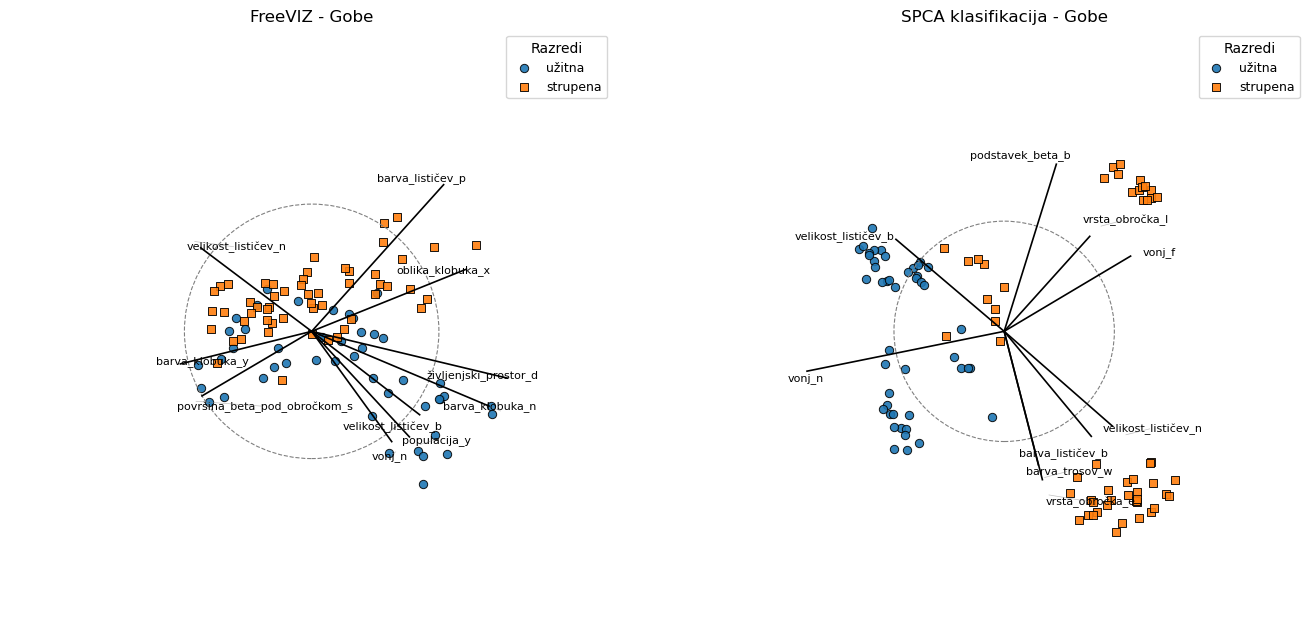

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    points=P_mush_np, vectors=A_mush_np, feature_names=feature_names_mush,
    class_codes=C_mush_np, class_names=class_names_mush,
    title='FreeVIZ - Gobe', ax=ax1, text_scale=1.08, top_n_loadings=10, normalize_points=True
)

plot_projection(
    points=Z_mush_np, vectors=L_mush_np, feature_names=feature_names_mush,
    class_codes=C_mush_np_spca, class_names=class_names_mush,
    title='SPCA klasifikacija - Gobe', ax=ax2, text_scale=1.1, top_n_loadings=10
)

plt.tight_layout()
plt.savefig("../final_vizualizations/compare_freeviz_spca_mushroom.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/compare_freeviz_spca_mushroom.png", format="png", bbox_inches="tight")
plt.show()

# The BREAST CANCER dataset

#### Data preparation

In [13]:
E_bc, C_bc, names_bc, feature_names_bc, class_names_bc = load_breast_cancer_data(device)
E_bc = scale_features(E_bc)

In [14]:
# Select optimal lambda for SPCA on Breast Cancer data
E_bc_f64 = E_bc.to(torch.float64)
best_lam_bc = select_lambda_classification(SPCA_Classification, E_bc_f64, C_bc,
                             num_classes=len(class_names_bc), steps=500)


Step 0: loss = 0.6682, classifier loss = 0.6668
Step 10: loss = 0.5222, classifier loss = 0.5205
Step 20: loss = 0.4396, classifier loss = 0.4377
Step 30: loss = 0.3811, classifier loss = 0.3792
Step 40: loss = 0.3378, classifier loss = 0.3359
Step 50: loss = 0.3048, classifier loss = 0.3028
Step 60: loss = 0.2788, classifier loss = 0.2767
Step 70: loss = 0.2579, classifier loss = 0.2558
Step 80: loss = 0.2408, classifier loss = 0.2386
Step 90: loss = 0.2266, classifier loss = 0.2244
Step 100: loss = 0.2147, classifier loss = 0.2125
Step 110: loss = 0.2087, classifier loss = 0.2064
Step 120: loss = 0.2075, classifier loss = 0.2052
Step 130: loss = 0.2063, classifier loss = 0.2040
Step 140: loss = 0.2052, classifier loss = 0.2028
Step 150: loss = 0.2040, classifier loss = 0.2017
Step 160: loss = 0.2029, classifier loss = 0.2006
Step 170: loss = 0.2018, classifier loss = 0.1995
Step 180: loss = 0.2008, classifier loss = 0.1984
Step 190: loss = 0.1997, classifier loss = 0.1973
Step 200: l

#### Train FreeVIZ

In [15]:
freeviz_bc = Freeviz(E_bc.shape[1]).to(device)
freeviz_bc.train(E_bc, C_bc)

P_bc = freeviz_bc(E_bc)
A_bc = freeviz_bc.A
P_bc_np = P_bc.detach().cpu().numpy()
C_bc_np = C_bc.detach().cpu().numpy()
A_bc_np = A_bc.detach().cpu().numpy()

step: 1 loss: 716257.75
step: 2 loss: 1011283.625
step: 3 loss: 869568.6875
step: 4 loss: 777568.1875
step: 5 loss: 810459.25
step: 6 loss: 680719.25
step: 7 loss: 696306.125
step: 8 loss: 705954.875
step: 9 loss: 671872.9375
step: 10 loss: 696420.3125
step: 11 loss: 1880516.625


#### Train SPCA Classification

In [16]:
model_bc = SPCA_Classification(input_dim=E_bc.shape[1], latent_dim=2, num_classes=len(class_names_bc), lr=0.05).to(device)
E_bc_centered = E_bc - E_bc.mean(dim=0)
model_bc.train(E_bc_centered, C_bc, lam=best_lam_bc, steps=1000, classifier_epochs=50)

L_bc = model_bc.L.detach().clone()
L_bc = L_bc - L_bc.mean(dim=0, keepdim=True)
loading_norms_bc = torch.norm(L_bc, dim=1)
L_bc = L_bc / loading_norms_bc.max()

Z_bc = E_bc_centered @ L_bc
z_max_bc = torch.abs(Z_bc).max()
Z_bc = Z_bc / z_max_bc

Z_bc_np = Z_bc.cpu().numpy()
C_bc_np_spca = C_bc.cpu().numpy()
L_bc_np = L_bc.cpu().numpy()

Step 0: loss = 1.9628, classifier loss = 0.6669
Step 10: loss = 1.8155, classifier loss = 0.5193
Step 20: loss = 1.7326, classifier loss = 0.4364
Step 30: loss = 1.6745, classifier loss = 0.3783
Step 40: loss = 1.6317, classifier loss = 0.3354
Step 50: loss = 1.5990, classifier loss = 0.3027
Step 60: loss = 1.5735, classifier loss = 0.2772
Step 70: loss = 1.5531, classifier loss = 0.2567
Step 80: loss = 1.5365, classifier loss = 0.2401
Step 90: loss = 1.5230, classifier loss = 0.2265
Step 100: loss = 1.5118, classifier loss = 0.2154
Step 110: loss = 1.5097, classifier loss = 0.2133
Step 120: loss = 1.5086, classifier loss = 0.2121
Step 130: loss = 1.5074, classifier loss = 0.2110
Step 140: loss = 1.5063, classifier loss = 0.2099
Step 150: loss = 1.5052, classifier loss = 0.2088
Step 160: loss = 1.5042, classifier loss = 0.2077
Step 170: loss = 1.5031, classifier loss = 0.2067
Step 180: loss = 1.5021, classifier loss = 0.2057
Step 190: loss = 1.5011, classifier loss = 0.2047
Step 200: l

### Side-by-side comparison

/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0


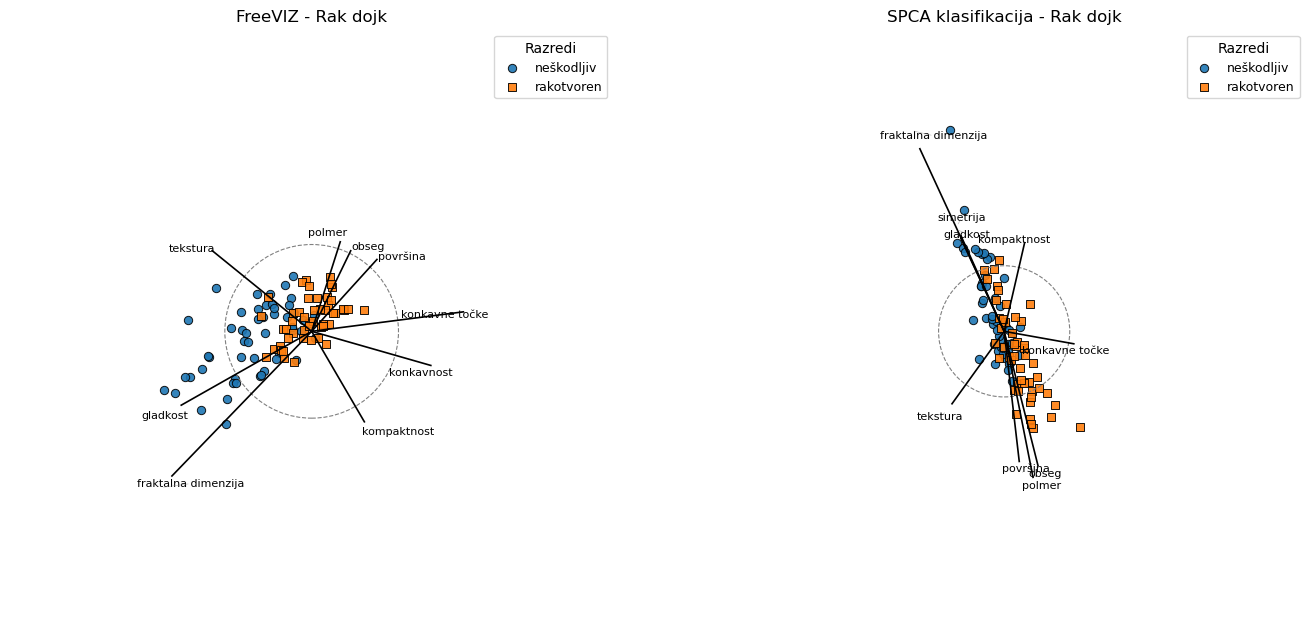

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    points=P_bc_np, vectors=A_bc_np, feature_names=feature_names_bc,
    class_codes=C_bc_np, class_names=class_names_bc,
    title='FreeVIZ - Rak dojk', ax=ax1, text_scale=1.08, top_n_loadings=10, normalize_points=True
)

plot_projection(
    points=Z_bc_np, vectors=L_bc_np, feature_names=feature_names_bc,
    class_codes=C_bc_np_spca, class_names=class_names_bc,
    title='SPCA klasifikacija - Rak dojk', ax=ax2, text_scale=1.1, top_n_loadings=10
)

plt.tight_layout()
plt.savefig("../final_vizualizations/compare_freeviz_spca_breast_cancer.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/compare_freeviz_spca_breast_cancer.png", format="png", bbox_inches="tight")
plt.show()